<a href="https://colab.research.google.com/github/rm571222/dataholics-oracle-challenge/blob/main/notebooks/01_data_exploration/nb2_data_exploration_leitos_cnes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NB2 — Data Exploration: Leitos SUS (CNES)

**Projeto DATAHOLICS — FIAP Challenge | Parceria Oracle**

Este notebook documenta a exploração da segunda fonte primária do projeto: o cadastro de **capacidade instalada de leitos** por estabelecimento de saúde.

## Fonte de dados

- **Sistema:** CNES (Cadastro Nacional de Estabelecimentos de Saúde) — módulo de Leitos
- **Publicação:** Ministério da Saúde, Portal de Dados Abertos
- **URL:** https://s3.sa-east-1.amazonaws.com/ckan.saude.gov.br/Leitos_SUS/Leitos_csv_2026.zip
- **Formato:** CSV, snapshot mensal (uma linha por hospital por competência)

## Estrutura deste notebook

1. Exploração inicial dos dados brutos
2. Seleção das principais variáveis + exploração/qualidade
3. Colunas de código — quais já vêm com descrição embutida, qual não vem
4. Fonte externa para a coluna sem descrição
5. Cruzamento de validação com a fonte SIH/pysus (NB1)

## 1. Exploração inicial dos dados brutos

In [15]:
import requests, zipfile, io
import pandas as pd
import matplotlib.pyplot as plt

resp = requests.get("https://s3.sa-east-1.amazonaws.com/ckan.saude.gov.br/Leitos_SUS/Leitos_csv_2026.zip")
z = zipfile.ZipFile(io.BytesIO(resp.content))

with z.open(z.namelist()[0]) as f:
    df_leitos_raw = pd.read_csv(f, sep=';', encoding='latin1')

print(f"Total de linhas (Brasil, todas as competências): {len(df_leitos_raw)}")
df_leitos_raw.info()

Total de linhas (Brasil, todas as competências): 50388
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50388 entries, 0 to 50387
Data columns (total 35 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   COMP                    50388 non-null  int64  
 1   REGIAO                  50388 non-null  object 
 2   UF                      50388 non-null  object 
 3   CO_IBGE                 50388 non-null  int64  
 4   MUNICIPIO               50388 non-null  object 
 5   MOTIVO_DESABILITACAO    0 non-null      float64
 6   CNES                    50388 non-null  int64  
 7   NOME_ESTABELECIMENTO    50388 non-null  object 
 8   RAZAO_SOCIAL            50388 non-null  object 
 9   TP_GESTAO               50388 non-null  object 
 10  CO_TIPO_UNIDADE         50388 non-null  int64  
 11  DS_TIPO_UNIDADE         50388 non-null  object 
 12  NATUREZA_JURIDICA       50388 non-null  int64  
 13  DESC_NATUREZA_JURIDICA  50388 non-nu

In [2]:
df_leitos_raw.head()

,COMP,REGIAO,UF,CO_IBGE,MUNICIPIO,MOTIVO_DESABILITACAO,CNES,NOME_ESTABELECIMENTO,RAZAO_SOCIAL,TP_GESTAO,...,UTI_ADULTO_EXIST,UTI_ADULTO_SUS,UTI_PEDIATRICO_EXIST,UTI_PEDIATRICO_SUS,UTI_NEONATAL_EXIST,UTI_NEONATAL_SUS,UTI_QUEIMADO_EXIST,UTI_QUEIMADO_SUS,UTI_CORONARIANA_EXIST,UTI_CORONARIANA_SUS
0,202601,NORDESTE,PE,260290,CABO DE SANTO AGOSTINHO,NaN,27,CASA DE SAUDE SANTA HELENA,CASA DE SAUDE E MATERNIDADE SANTA HELENA LTDA,M,...,0,0,0,0,0,0,0,0,0,0
1,202601,NORDESTE,PE,260290,CABO DE SANTO AGOSTINHO,NaN,35,HOSPITAL MENDO SAMPAIO,PREFEITURA MUNICIPAL DO CABO DE SANTO AGOSTINHO,M,...,0,0,0,0,0,0,0,0,0,0
2,202601,NORDESTE,PE,260290,CABO DE SANTO AGOSTINHO,NaN,94,MATERNIDADE PADRE GERALDO LEITE BASTOS,PREFEITURA MUNICIPAL DO CABO DE SANTO AGOSTINHO,M,...,0,0,0,0,0,0,0,0,0,0
3,202601,NORDESTE,PE,260290,CABO DE SANTO AGOSTINHO,NaN,183,HOSPITAL SAMARITANO,SOCIEDADE HOSPITALAR SAMARITANO LTDA,M,...,0,0,0,0,0,0,0,0,0,0
4,202601,NORDESTE,PE,260290,CABO DE SANTO AGOSTINHO,NaN,221,HOSPITAL SAO SEBASTIAO,CASA DE SAUDE E MATERNIDADE SAO SEBASTIAO LTDA,M,...,10,0,0,0,0,0,0,0,0,0


## 2. Seleção das principais variáveis + exploração/qualidade

Das 35 colunas disponíveis, selecionamos 9 relevantes para o projeto (identificação do hospital, localização e capacidade de leitos). O arquivo traz snapshots mensais — usamos a **última competência disponível por hospital individualmente** (não uma competência única fixa), para não perder hospitais que saíram do cadastro antes da competência mais recente. A seleção foi realizada para o Estado de São Paulo.

In [3]:
df_sp = (
    df_leitos_raw[df_leitos_raw['UF'] == 'SP']
    .sort_values('COMP')
    .drop_duplicates(subset='CNES', keep='last')
    .copy()
)
print(f"Hospitais únicos em SP (última competência disponível por hospital): {len(df_sp)}")

colunas_banco = ['CNES', 'CO_IBGE', 'LEITOS_EXISTENTES', 'LEITOS_SUS',
                  'UTI_TOTAL_EXIST', 'UTI_TOTAL_SUS',
                  'UTI_ADULTO_EXIST', 'UTI_PEDIATRICO_EXIST', 'UTI_NEONATAL_EXIST']

print(f"\nDuplicatas de CNES: {df_sp['CNES'].duplicated().sum()}")
print(f"\nNulos nas colunas selecionadas:")
print(df_sp[colunas_banco].isna().sum())

Hospitais únicos em SP (última competência disponível por hospital): 1053

Duplicatas de CNES: 0

Nulos nas colunas selecionadas:
CNES                    0
CO_IBGE                 0
LEITOS_EXISTENTES       0
LEITOS_SUS              0
UTI_TOTAL_EXIST         0
UTI_TOTAL_SUS           0
UTI_ADULTO_EXIST        0
UTI_PEDIATRICO_EXIST    0
UTI_NEONATAL_EXIST      0
dtype: int64


In [4]:
def resumo_coluna(serie):
    vazio = serie.isna() | (serie.astype(str).str.strip().isin(['', '0', '00', '000', 'nan', 'None']))
    return pd.Series({
        'pct_preenchido': round((1 - vazio.mean()) * 100, 1),
        'valores_distintos': serie.nunique(),
        'exemplo': serie.dropna().iloc[0] if serie.notna().any() else None
    })

resumo_leitos = df_sp[colunas_banco].apply(resumo_coluna).T
print(resumo_leitos)

                      pct_preenchido  valores_distintos    exemplo
CNES                           100.0             1053.0  3071448.0
CO_IBGE                        100.0              354.0   354730.0
LEITOS_EXISTENTES              100.0              296.0       20.0
LEITOS_SUS                      61.5              227.0       20.0
UTI_TOTAL_EXIST                 50.0               94.0        0.0
UTI_TOTAL_SUS                   26.5               70.0        0.0
UTI_ADULTO_EXIST                45.8               70.0        0.0
UTI_PEDIATRICO_EXIST            19.9               33.0        0.0
UTI_NEONATAL_EXIST              22.0               27.0        0.0


In [5]:
# Consistência: leitos SUS nunca pode ser maior que leitos existentes
inconsistente_leitos = df_sp[df_sp['LEITOS_SUS'] > df_sp['LEITOS_EXISTENTES']]
print(f"LEITOS_SUS > LEITOS_EXISTENTES: {len(inconsistente_leitos)}")

for tipo in ['UTI_TOTAL', 'UTI_ADULTO', 'UTI_PEDIATRICO', 'UTI_NEONATAL']:
    col_exist, col_sus = f'{tipo}_EXIST', f'{tipo}_SUS'
    inconsistente = df_sp[df_sp[col_sus] > df_sp[col_exist]]
    print(f"{col_sus} > {col_exist}: {len(inconsistente)}")

print(f"\nLEITOS_EXISTENTES < 0: {(df_sp['LEITOS_EXISTENTES'] < 0).sum()}")
print(f"LEITOS_EXISTENTES > 2000: {(df_sp['LEITOS_EXISTENTES'] > 2000).sum()}")
print(f"LEITOS_EXISTENTES = 0: {(df_sp['LEITOS_EXISTENTES'] == 0).sum()}")

LEITOS_SUS > LEITOS_EXISTENTES: 0
UTI_TOTAL_SUS > UTI_TOTAL_EXIST: 0
UTI_ADULTO_SUS > UTI_ADULTO_EXIST: 0
UTI_PEDIATRICO_SUS > UTI_PEDIATRICO_EXIST: 0
UTI_NEONATAL_SUS > UTI_NEONATAL_EXIST: 0

LEITOS_EXISTENTES < 0: 0
LEITOS_EXISTENTES > 2000: 0
LEITOS_EXISTENTES = 0: 0


**Resultado:** zero inconsistências estruturais — nenhuma linha com leitos SUS maior que existentes, nenhum valor negativo ou absurdamente grande. O dado de leitos é internamente consistente.

**Nota sobre a taxa de preenchimento:** as colunas de UTI (`UTI_TOTAL_EXIST`, `UTI_ADULTO_EXIST`, `UTI_PEDIATRICO_EXIST`, `UTI_NEONATAL_EXIST`) e `LEITOS_SUS` aparecem com preenchimento entre 19,9% e 61,5% na métrica acima. Na prática, é esperado que boa parte dos hospitais tenha `0` leitos de UTI pediátrica ou neonatal, por exemplo, já que essas são especialidades restritas a poucos estabelecimentos de maior complexidade.

## 3. Colunas de código — o que já vem com descrição e o que não vem

Duas colunas de código do arquivo já trazem a descrição embutida, sem necessidade de fonte externa:

In [6]:
print("CO_TIPO_UNIDADE (já com descrição embutida):")
print(df_sp[['CO_TIPO_UNIDADE', 'DS_TIPO_UNIDADE']].drop_duplicates().head(10))

print("\nNATUREZA_JURIDICA (já com descrição embutida):")
print(df_sp[['NATUREZA_JURIDICA', 'DESC_NATUREZA_JURIDICA']].drop_duplicates().head(10))

CO_TIPO_UNIDADE (já com descrição embutida):
       CO_TIPO_UNIDADE               DS_TIPO_UNIDADE
5125                 5                HOSPITAL GERAL
5630                20          PRONTO SOCORRO GERAL
7446                15                 UNIDADE MISTA
14702                7        HOSPITAL ESPECIALIZADO
43478               21  PRONTO SOCORRO ESPECIALIZADO

NATUREZA_JURIDICA (já com descrição embutida):
       NATUREZA_JURIDICA DESC_NATUREZA_JURIDICA
5125                1244       HOSPITAL_PÚBLICO
305                 2062       HOSPITAL_PRIVADO
13879               2054       HOSPITAL_PRIVADO
36330               2143       HOSPITAL_PRIVADO
50301               3999  HOSPITAL_FILANTRÓPICO
50250               1023       HOSPITAL_PÚBLICO
50228               3069  HOSPITAL_FILANTRÓPICO
43427               1031       HOSPITAL_PÚBLICO
43804               1112       HOSPITAL_PÚBLICO
43831               1210       HOSPITAL_PÚBLICO


Já `TP_GESTAO` **não vem** com descrição no arquivo — exige fonte/hipótese externa.

In [7]:
print(df_sp['TP_GESTAO'].value_counts())

TP_GESTAO
M    892
E    161
Name: count, dtype: int64


## 4. Fonte externa para `TP_GESTAO`

O mesmo padrão de código (`M`/`E`/`D`) já havia sido documentado no cadastro CNES de estabelecimentos (ver NB3) — usamos essa mesma referência aqui, por consistência:

| Código | Descrição |
|---|---|
| M | Municipal |
| E | Estadual |
| D | Dupla |

In [8]:
desc_tp_gestao = {'M': 'Municipal', 'E': 'Estadual', 'D': 'Dupla'}
cobertura_gestao = df_sp['TP_GESTAO'].isin(desc_tp_gestao.keys()).mean() * 100
print(f"Cobertura do domínio proposto: {cobertura_gestao:.2f}%")
print(f"\nValores observados na prática:")
print(df_sp['TP_GESTAO'].map(desc_tp_gestao).value_counts())

Cobertura do domínio proposto: 100.00%

Valores observados na prática:
TP_GESTAO
Municipal    892
Estadual     161
Name: count, dtype: int64


**Observação:** embora `D` (Dupla) exista no domínio documentado, **nunca foi observado** nos dados reais de SP — apenas `M` e `E` aparecem na prática. Isso é registrado como nota, não como erro.

## 5. Cruzamento de validação com a fonte SIH/pysus (NB1)

Validamos aqui se os hospitais que efetivamente geraram internação no SIH (fonte primária, NB1) têm correspondência no cadastro de Leitos.

In [ ]:
!pip install -q pysus

from pysus import sih
import pandas as pd

MESES_AMOSTRA = [(2026, m) for m in range(1, 7)]  # jan a jun/2026

dfs_amostra = []
for ano, mes in MESES_AMOSTRA:
    try:
        caminhos = sih(state="SP", year=ano, month=mes)
        caminhos_rd = [p for p in caminhos if "RDSP" in p.upper()]
        if caminhos_rd:
            dfs_amostra.append(pd.concat([pd.read_parquet(p) for p in caminhos_rd], ignore_index=True))
    except Exception as e:
        print(f'{ano}-{mes:02d} falhou: {e}')

df_sih = pd.concat(dfs_amostra, ignore_index=True)
print(f"Total de registros na amostra (SIH): {len(df_sih)}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 351.4/351.4 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.7/247.7 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.5/63.5 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 49.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.4/322.4 kB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.5/21.5 MB 73.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 76.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.3/58.3 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 80.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.0/56.0

/tmp/ipykernel_3939/3328591291.py:11: PySUSWarning: pysus.sih() is deprecated and will be removed. Use the origin-namespaced API instead, e.g. pysus.ftp.sih(...), pysus.dadosgov.sih(...), or pysus.saude.sih(...). Behavior is unchanged.
  caminhos = sih(state="SP", year=ano, month=mes)
ERSP2601.parquet: 0.00B [00:00, ?B/s]

RDSP2601.parquet: 0.00B [00:00, ?B/s]


RJSP2601.parquet: 0.00B [00:00, ?B/s]


RJSP2601.parquet:   0%|          | 0.00/676k [00:00<?, ?B/s]


RJSP2601.parquet:  10%|▉         | 65.5k/676k [00:00<00:00, 16.4MB/s]


RJSP2601.parquet:  19%|█▉        | 131k/676k [00:00<00:00, 1.45MB/s] 
ERSP2601.parquet:   0%|          | 0.00/296k [00:00<?, ?B/s]
ERSP2601.parquet:  22%|██▏       | 65.5k/296k [00:00<00:00, 13.0MB/s]


RJSP2601.parquet:  29%|██▉       | 197k/676k [00:00<00:00, 1.42MB/s]


RJSP2601.parquet:  39%|███▉      | 262k/676k [00:00<00:00, 1.48MB/s]


RJSP2601.parquet:  48%|████▊     | 328k/676k [00:00<00:00, 1.52MB/s]
ERSP2601.parquet:  44%|████▍     | 131k/296k [

In [13]:
# hospitais_fato: extraído diretamente do DataFrame do SIH (NB1), não de nenhum banco de dados
hospitais_fato = set(df_sih['CNES'].astype(str).str.strip())
hospitais_leitos = set(df_sp['CNES'].astype(str))

sem_leitos = hospitais_fato - hospitais_leitos
print(f"Hospitais únicos no SIH: {len(hospitais_fato)}")
print(f"Com correspondência no cadastro de Leitos: {len(hospitais_fato & hospitais_leitos)}")
print(f"Sem correspondência: {len(sem_leitos)} ({len(sem_leitos)/len(hospitais_fato)*100:.2f}%)")

Hospitais únicos no SIH: 626
Com correspondência no cadastro de Leitos: 552
Sem correspondência: 74 (11.82%)


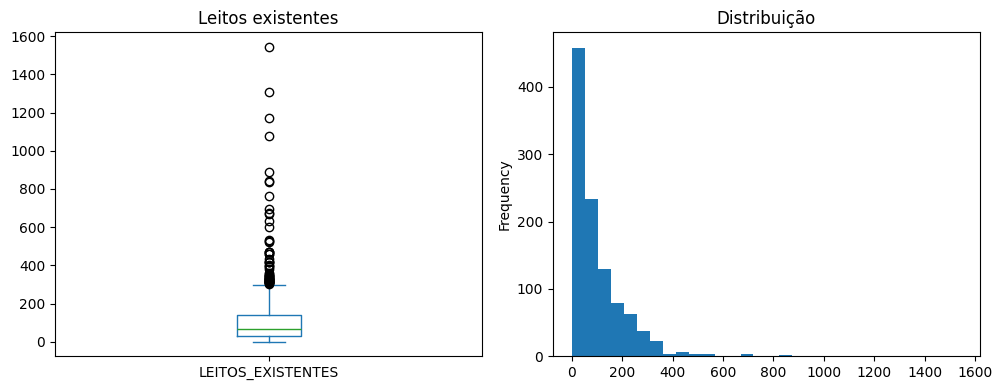

,LEITOS_EXISTENTES,LEITOS_SUS
0.50,66.00,18.00
0.75,138.00,71.00
0.90,243.40,178.60
0.95,303.20,246.80
0.99,649.68,450.24


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df_sp['LEITOS_EXISTENTES'].plot(kind='box', ax=axes[0], title='Leitos existentes')
df_sp['LEITOS_EXISTENTES'].plot(kind='hist', bins=30, ax=axes[1], title='Distribuição')
plt.tight_layout()
plt.show()

df_sp[['LEITOS_EXISTENTES', 'LEITOS_SUS']].quantile([0.5, 0.75, 0.9, 0.95, 0.99])

In [17]:
df_sp.nlargest(10, 'LEITOS_EXISTENTES')[['CNES', 'LEITOS_EXISTENTES', 'LEITOS_SUS', 'UTI_TOTAL_EXIST']]

,CNES,LEITOS_EXISTENTES,LEITOS_SUS,UTI_TOTAL_EXIST
43857,2078015,1543,1476,227
43828,2077396,1307,876,275
47324,2688689,1174,1080,184
44093,2082187,1079,1021,142
44000,2080575,887,252,243
43835,2077485,842,798,117
43804,2058502,836,6,37
44186,2085143,761,294,0
43802,2058391,696,28,94
47642,2748223,674,535,74


In [18]:
resumo_tipo_unidade = df_sp.groupby('DS_TIPO_UNIDADE').agg(
    qtd_hospitais=('CNES', 'count'),
    total_leitos=('LEITOS_EXISTENTES', 'sum'),
    media_leitos=('LEITOS_EXISTENTES', 'mean')
).sort_values('total_leitos', ascending=False)
resumo_tipo_unidade

resumo_natureza = df_sp.groupby('DESC_NATUREZA_JURIDICA').agg(
    qtd_hospitais=('CNES', 'count'),
    total_leitos=('LEITOS_EXISTENTES', 'sum')
).sort_values('total_leitos', ascending=False)
resumo_natureza

,qtd_hospitais,total_leitos
DESC_NATUREZA_JURIDICA,,
HOSPITAL_FILANTRÓPICO,405,51983
HOSPITAL_PÚBLICO,270,31447
HOSPITAL_PRIVADO,378,27883


In [19]:
composicao_uti = df_sp[['UTI_ADULTO_EXIST', 'UTI_PEDIATRICO_EXIST', 'UTI_NEONATAL_EXIST']].sum()
composicao_uti_pct = (composicao_uti / composicao_uti.sum() * 100).round(1)
composicao_uti_pct

,0
UTI_ADULTO_EXIST,70.6
UTI_PEDIATRICO_EXIST,13.9
UTI_NEONATAL_EXIST,15.5


In [ ]:
# Investigação do residual: volume de internação desses hospitais e especialidade de leito
df_sih_sem_leitos = df_sih[df_sih['CNES'].astype(str).str.strip().isin(sem_leitos)]
print(f"Internações vindas desses hospitais sem correspondência: {len(df_sih_sem_leitos)} ({len(df_sih_sem_leitos)/len(df_sih)*100:.2f}% do total)")

especialidades_confirmadas = {
    '01': 'Cirurgia geral',
    '02': 'Obstetrícia',
    '03': 'Clínica médica',
    '04': 'Crônico e FPT (fora de possibilidade terapêutica)',
    '05': 'Psiquiatria',
    '06': 'Tisiologia',
    '07': 'Pediatria',
    '08': 'Reabilitação',
    '09': 'Psiquiatria - hospital/dia'
}

contagem_espec = df_sih_sem_leitos['ESPEC'].value_counts()
contagem_com_descricao = contagem_espec.rename(
    index=lambda cod: f"{cod} - {especialidades_confirmadas.get(cod, 'NÃO CONFIRMADO')}"
)
print(contagem_com_descricao)

### Esclarecimento da inconsistência: hospitais sem correspondência

A investigação (cruzando nome do estabelecimento via cadastro CNES completo) revelou que os hospitais sem correspondência são, em sua maioria, estabelecimentos que **por natureza não operam com leito de internação formal**: Hospital-Dia, AME (Ambulatório Médico de Especialidades), UPA (Unidade de Pronto Atendimento) e Pronto-Socorro — que emitem AIH por regras administrativas do SUS, sem possuir estrutura de leito. Isso é coerente com a distribuição de especialidade de leito (`ESPEC`) observada nesses hospitais, que mistura códigos de hospital-dia com especialidades convencionais (clínica médica, cirurgia, obstetrícia) — plausível para unidades que atendem esses casos sem pernoite formal.

## Dicionário de dados — variáveis selecionadas (Leitos SUS)

| Coluna | Descrição |
|---|---|
| `CNES` | Código do estabelecimento (chave) |
| `CO_IBGE` | Município do estabelecimento |
| `LEITOS_EXISTENTES` | Total de leitos instalados |
| `LEITOS_SUS` | Total de leitos disponíveis ao SUS |
| `UTI_TOTAL_EXIST` / `UTI_TOTAL_SUS` | Leitos de UTI (total e disponíveis ao SUS) |
| `UTI_ADULTO_EXIST` | Leitos de UTI adulto |
| `UTI_PEDIATRICO_EXIST` | Leitos de UTI pediátrico |
| `UTI_NEONATAL_EXIST` | Leitos de UTI neonatal |
| `TP_GESTAO` | Tipo de gestão do hospital (M/E/D) |
| `CO_TIPO_UNIDADE` / `DS_TIPO_UNIDADE` | Tipo de unidade, já com descrição embutida |
| `NATUREZA_JURIDICA` / `DESC_NATUREZA_JURIDICA` | Natureza jurídica, já com descrição embutida |

## Mini KPIs — capacidade instalada

In [22]:
print(f"Total de leitos existentes (SP): {df_sp['LEITOS_EXISTENTES'].sum():,}")
print(f"Total de leitos SUS (SP): {df_sp['LEITOS_SUS'].sum():,}")
print(f"% de leitos que são SUS: {df_sp['LEITOS_SUS'].sum() / df_sp['LEITOS_EXISTENTES'].sum() * 100:.1f}%")
print(f"\nMédia de leitos por hospital: {df_sp['LEITOS_EXISTENTES'].mean():.1f}")
print(f"Mediana de leitos por hospital: {df_sp['LEITOS_EXISTENTES'].median():.1f}")
print(f"\nDistribuição por tipo de gestão:")
print(df_sp['TP_GESTAO'].map(desc_tp_gestao).value_counts(normalize=True).mul(100).round(1))
print(f"\n% de hospitais com pelo menos 1 leito de UTI: {(df_sp['UTI_TOTAL_EXIST'] > 0).mean()*100:.1f}%")

Total de leitos existentes (SP): 111,313
Total de leitos SUS (SP): 62,250
% de leitos que são SUS: 55.9%

Média de leitos por hospital: 105.7
Mediana de leitos por hospital: 66.0

Distribuição por tipo de gestão:
TP_GESTAO
Municipal    84.7
Estadual     15.3
Name: proportion, dtype: float64

% de hospitais com pelo menos 1 leito de UTI: 50.0%


## Conclusão da exploração — NB2

A exploração do cadastro de Leitos SUS resultou em: (1) seleção de 9 variáveis de capacidade instalada; (2) zero inconsistências estruturais nos dados; (3) identificação de duas colunas já com descrição embutida no arquivo (tipo de unidade e natureza jurídica), evitando fonte externa desnecessária; (4) validação de cobertura de correspondência com o SIH ao usar a última competência disponível por hospital, evitando perder estabelecimentos que saíram do cadastro antes da competência mais recente; (5) esclarecimento do residual remanescente como legítimo (estabelecimentos que, por natureza, não operam com leito de internação formal). Essas variáveis compõem a base para a dimensão de capacidade hospitalar do modelo físico.